## 프롬프팅
- 제로샷 : 사전 예시나 형태를 제공하지 않고 지시문만을 입력하여 결과를 도출하는 기법
    - 프롬프트 작성이 빠르고 언어 번역, 간단한 문장 요약, 보편적인 지식 검색 같은 일상적이고 단순한 작업에 유리
- 퓨샷 : 지시문과 함께 모델이 참고 할 수 있는 예시를 프롬프트 내에 포함하여 질문하는 구조적 기법
    - 모델의 내부 가중치를 변경하는 고비용의 파인 튜닝 과정 없이 컨텐스트 윈도우내에서 예시의 패턴을 즉각 인지하여 다음 단어 예측 확률을 조정하는 문맥 내 학습 메커니즘
    - 결과물 형식과 톤앤매너 통제가 가능, 고객 문의 메일을 표 형태로 분류하거나 특정 코딩 스타일을 적용하는 등 복잡한 패턴 인식 작업에 탁월
    - 예시 작성에 시간이 소요 되며 제공된 예시 자체에 편향이나 논리적 오류가 포함되어 있다면 인공지능이 이를 그대로 답습하므로 비판적 사고를 통한 사전 검수가 필수
    

## 머신러닝
- 패키지 설치
    - uv add numpy  (주피터 노트북 필요시 ipykernel 설치)
    - uv add pandas

### Pandas
- 뷰와 복사
    - 데이터를 조건에 맞게 잘라낼때 원본을 가리키는 뷰를 줄지 보사본을 줄지에 대한 솔루션.
        - 데이터 수정 하다 원본이 오염되는것에 대한 경고가 자주 발생해왔음
    1. Copy-on-Win을 작동. 데이터를 조회 할때는 원본을 공유하다 데이터를 수정(Write) 하려는 순간 독립적인 복사본을 만들어 원본을 보호
    2. 데이터를 수정할때 대괄호를 여러번 쓰는 것(df[A][B])보다 .loc[] 기능을 사용하여 한번에 위치를 지정.
        - 대괄호의 연속 사용(df['A']['B'] = value) : 두 개의 독립적인 단계로 처리. 중간에 임시 복사본이 생성될 수 있어 원본 데이터 수정이 보장되지 않음
        - .loc[] 및 .iloc[] 사용 : 하나의 단일 작업으로 처리. 원본 데이터의 정확한 메모리 위치로 직행하므로 100% 완전하게 수정됨


In [ ]:

#데이터 불러오기
import pandas as pd

df = pd.read_csv('../../dataset.csv')
df.info()
print("-" * 100)
df.describe()

In [ ]:
# 결측치 확인 하기
df.isnull().sum()

In [ ]:
df_indexed = df.set_index('artists')

#df_indexed
df_indexed.loc['Gen Hoshino']


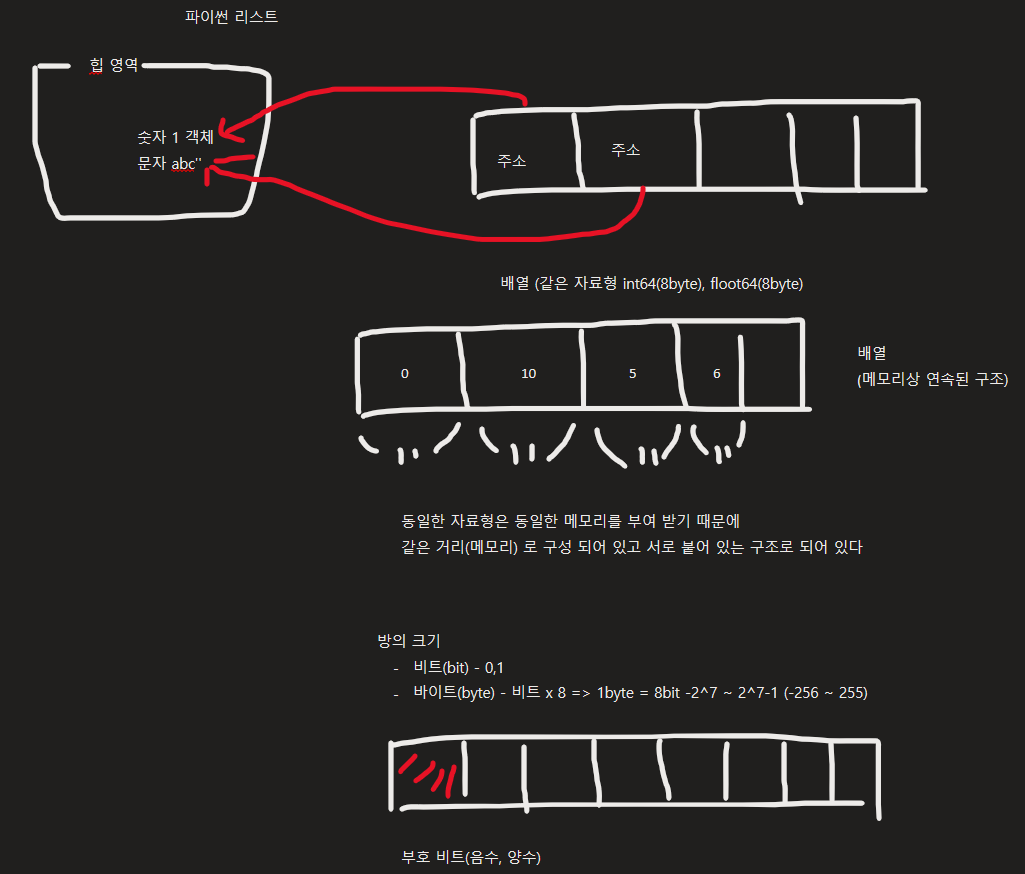

- 파이썬의 리스트는 값의 주소를 참조하여 가져오므로 각 값의 위치가 제각각이다
- 배열은 해당 자료형이 필요한 메모리만큼 확보하여 동일한 크기를 가진 메모리를 나열하여 배치한다
    - 검색 속도가 빠르다 (바로 옆 메모리가 다음 값이므로)

In [ ]:
#numpy 추가
import numpy as np

nums = np.array([10,20,30], dtype=np.float64) # 1차원 배열(vector)
nums

In [ ]:
matrix = np.array([
    [10,20,30],
    [40,50,60],
    [70,80,90]
]) # 2차원 배열(Matrix)

print(matrix[0:2,1:3]) # 행은 0,1 열은 1,2
print(matrix[:,0]) # 행은 전체 열은 0
print(matrix[1:,:2]) # 행은 1번 인덱스 부터 전체, 열은 1번 인덱스 이하

In [ ]:
arr = np.arange(1,13) # 1~12 생성 range(1,12)랑 비슷
mat_3x4 = arr.reshape(3,4) #3행 4열로
mat_3x4 = arr.reshape(3,-1) #3행 가능한 열로
mat_3x4 = arr.reshape(-1,4) #가능한 행 4열   -> 가능한 -> 행,열 한쪽이 지정된 후 가능한 만큼으로 지정

print(mat_3x4)

flat_arr = mat_3x4.flatten() # 2차원 배열을 1차원으로 평탄화
print(flat_arr)

In [ ]:
mat = np.arange(1,7).reshape(2,-1)

print(mat)

sum_axis0 = mat.sum(axis=0)
sum_axis1 = mat.sum(axis=1)

print(sum_axis0) # 행기준 합계
print(sum_axis1) # 열기준 합계

In [ ]:
# 브로드캐스팅 연산

print(mat*5) # 배열의 각 값에 동일하게 연산

vec = np.array([1,2,3])

mat + vec # 행의 각 값에 연산, 열의 수가 맞지 않으면 연산 불가

In [ ]:
mat = np.array([
    [1,2,3],
    [4,5,6]
])

print(mat)
print(mat.transpose()) # 행,열 -> 열, 행 으로 전치
print(mat.T) # T로도 됨

In [ ]:
mat1 = np.array([[10,20],[30,40]])
mat2 = np.array([[1,2],[4,5]])

mat3 = mat1 @ mat2 # 행렬 곱 연산   10 20  x 1 2  = (10x1+20x4) (10x2 + 20x5)
                   #              30 40    4 5  = (30x1+40x4) (30x2 + 40x5)

mat3